In [ ]:
# ===============================================================
# ΕΡΓΑΣΤΗΡΙΟ: Κανονικοποίηση & Προεπεξεργασία Δεδομένων
# Μάθημα: Εισαγωγή στην Εξόρυξη Δεδομένων
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [ ]:
# ---------------------------------------------------------------
# Άσκηση 1: Δημιουργία μικρού συνόλου δεδομένων
# ---------------------------------------------------------------
# Στόχος: Να δημιουργηθεί ένα dataset με μεταβλητές "Ηλικία", "Εισόδημα" και "Φύλο".
# Θα το χρησιμοποιήσουμε σε όλες τις επόμενες ασκήσεις.
# Περιέχει και μία ελλιπή τιμή (NaN) στην ηλικία, ώστε να εφαρμοστεί καθαρισμός.

data = {
    'Age': [25, 30, 28, 40, 50, np.nan, 33],
    'Income': [30000, 40000, 35000, 50000, 90000, 60000, 45000],
    'Gender': ['M', 'F', 'F', 'M', 'M', 'F', 'F']
}

df = pd.DataFrame(data)
print("🔹 Αρχικά δεδομένα:\n", df)

🔹 Αρχικά δεδομένα:
     Age  Income Gender
0  25.0   30000      M
1  30.0   40000      F
2  28.0   35000      F
3  40.0   50000      M
4  50.0   90000      M
5   NaN   60000      F
6  33.0   45000      F


In [ ]:
# ---------------------------------------------------------------
# Άσκηση 2: Καθαρισμός δεδομένων (Data Cleaning)
# ---------------------------------------------------------------
# Στόχος: Να συμπληρώσουμε την ελλιπή τιμή (NaN) στη στήλη "Age".
# Χρησιμοποιούμε τη μέθοδο Imputation (αντικατάσταση με μέσο όρο).

imputer = SimpleImputer(strategy='mean')
df['Age'] = imputer.fit_transform(df[['Age']])

print("\n Μετά τον καθαρισμό των ελλειπουσών τιμών:\n", df)


 Μετά τον καθαρισμό των ελλειπουσών τιμών:
          Age  Income Gender
0  25.000000   30000      M
1  30.000000   40000      F
2  28.000000   35000      F
3  40.000000   50000      M
4  50.000000   90000      M
5  34.333333   60000      F
6  33.000000   45000      F


In [ ]:
# ---------------------------------------------------------------
#  Άσκηση 3: Κανονικοποίηση - Min–Max & Z-score
# ---------------------------------------------------------------
# Στόχος: Να μετασχηματίσουμε τα δεδομένα ώστε να βρίσκονται στην ίδια κλίμακα.
# Θα χρησιμοποιήσουμε δύο διαφορετικές μεθόδους κανονικοποίησης:
# - Min–Max: φέρνει τιμές στο [0,1]
# - Z-score: μετατρέπει τις τιμές σε τυποποιημένες μονάδες (με βάση μέσο και τυπική απόκλιση)

scaler_minmax = MinMaxScaler()
scaler_zscore = StandardScaler()

df_minmax = df.copy()
df_minmax[['Age', 'Income']] = scaler_minmax.fit_transform(df[['Age', 'Income']])

df_zscore = df.copy()
df_zscore[['Age', 'Income']] = scaler_zscore.fit_transform(df[['Age', 'Income']])

print("\n Min–Max Normalization:\n", df_minmax)
print("\n Z–Score Normalization:\n", df_zscore)



 Min–Max Normalization:
         Age    Income Gender
0  0.000000  0.000000      M
1  0.200000  0.166667      F
2  0.120000  0.083333      F
3  0.600000  0.333333      M
4  1.000000  1.000000      M
5  0.373333  0.500000      F
6  0.320000  0.250000      F

 Z–Score Normalization:
         Age    Income Gender
0 -1.197350 -1.069045      M
1 -0.555912 -0.534522      F
2 -0.812487 -0.801784      F
3  0.726962  0.000000      M
4  2.009837  2.138090      M
5  0.000000  0.534522      F
6 -0.171050 -0.267261      F


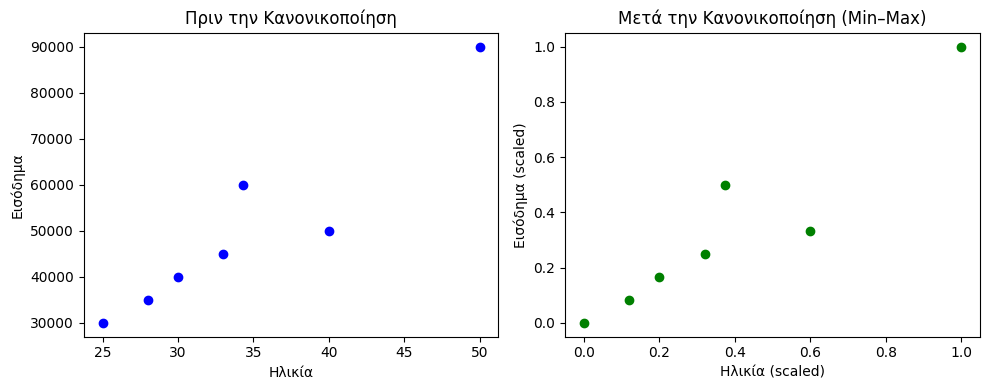

In [ ]:
# ---------------------------------------------------------------
#  Άσκηση 5: Οπτικοποίηση πριν και μετά την Κανονικοποίηση
# ---------------------------------------------------------------
# Στόχος: Να δούμε γραφικά πώς αλλάζει η γεωμετρία των σημείων
# μετά την εφαρμογή Min–Max κανονικοποίησης.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df['Age'], df['Income'], color='blue')
axes[0].set_title("Πριν την Κανονικοποίηση")
axes[0].set_xlabel("Ηλικία")
axes[0].set_ylabel("Εισόδημα")

axes[1].scatter(df_minmax['Age'], df_minmax['Income'], color='green')
axes[1].set_title("Μετά την Κανονικοποίηση (Min–Max)")
axes[1].set_xlabel("Ηλικία (scaled)")
axes[1].set_ylabel("Εισόδημα (scaled)")

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------------
#  Άσκηση 7: Διακριτοποίηση (Discretization)
# ---------------------------------------------------------------
# Στόχος: Να χωρίσουμε συνεχείς τιμές σε κατηγορίες (bins).
# Θα κάνουμε:
#  - Διακριτοποίηση ηλικίας σε 3 κατηγορίες ίσου πλάτους (Equal-Width)
#  - Διακριτοποίηση εισοδήματος σε 3 κατηγορίες ίσης συχνότητας (Equal-Frequency)
# -------------------------------------------------------------------
# 1️⃣ Equal-Width Binning (Ίσο Πλάτος)
# -------------------------------------------------------------------
# ➤ Η μέθοδος χωρίζει το εύρος των τιμών σε διαστήματα ίσου πλάτους.
# Δηλαδή, αν η μικρότερη ηλικία είναι 25 και η μεγαλύτερη 50, τότε:
#  - Το εύρος είναι 50 - 25 = 25
#  - Αν θέλουμε 3 διαστήματα, κάθε διάστημα έχει πλάτος 25/3 ≈ 8.33
#
# Άρα τα διαστήματα είναι περίπου:
# [25–33.33), [33.33–41.66), [41.66–50]
#
# # -------------------------------------------------------------------
# 2️⃣ Equal-Frequency Binning (Ίση Συχνότητα)
# -------------------------------------------------------------------
# ➤ Αυτή η μέθοδος φροντίζει ώστε κάθε διάστημα να περιέχει
# περίπου τον ίδιο αριθμό παρατηρήσεων (ίση συχνότητα).
# Αν έχουμε 9 άτομα και 3 διαστήματα, κάθε κατηγορία θα έχει περίπου 3 άτομα.
#
# Η συνάρτηση pd.qcut() "κόβει" τα δεδομένα με βάση τα τεταρτημόρια (quantiles),
# ώστε κάθε bin να περιέχει το ίδιο ποσοστό των δεδομένων.
#
# Έτσι, οι τιμές εισοδήματος θα χωριστούν σε 3 κατηγορίες:
# - Χαμηλό (χαμηλότερα εισοδήματα)
# - Μέσο (μεσαία εισοδήματα)
# - Υψηλό (υψηλότερα εισοδήματα)
# Κάθε τιμή αντιστοιχίζεται σε μία από τις 3 κατηγορίες.
# Στο pandas αυτό γίνεται εύκολα με τη συνάρτηση pd.cut().
# P=(n−1)×q+1
# όπου:
#
# 𝑛
# n = πλήθος τιμών (εδώ 7)
#
# 𝑞
# q = ποσοστό (εδώ 0.33)

print("Αρχικά δεδομένα (πριν τη διακριτοποίηση):\n")
print(df[['Age', 'Income']])

df['Age_Bins_EqualWidth'] = pd.cut(df['Age'], bins=3, labels=["Νέος", "Μέσος", "Μεγαλύτερος"])
df['Income_Bins_EqualFreq'] = pd.qcut(df['Income'], q=3, labels=["Χαμηλό", "Μέσο", "Υψηλό"])

print("\n Διακριτοποίηση μεταβλητών:\n", df[['Age', 'Age_Bins_EqualWidth', 'Income', 'Income_Bins_EqualFreq']])


🔹 Αρχικά δεδομένα (πριν τη διακριτοποίηση):

         Age  Income
0  25.000000   30000
1  30.000000   40000
2  28.000000   35000
3  40.000000   50000
4  50.000000   90000
5  34.333333   60000
6  33.000000   45000

 Διακριτοποίηση μεταβλητών:
          Age Age_Bins_EqualWidth  Income Income_Bins_EqualFreq
0  25.000000                Νέος   30000                Χαμηλό
1  30.000000                Νέος   40000                Χαμηλό
2  28.000000                Νέος   35000                Χαμηλό
3  40.000000               Μέσος   50000                 Υψηλό
4  50.000000         Μεγαλύτερος   90000                 Υψηλό
5  34.333333               Μέσος   60000                 Υψηλό
6  33.000000                Νέος   45000                  Μέσο
